# Projektin Nimi (TBD)

Tony Karlin, Onni Kivinen, Joni Heikkilä, Jarkko Kärki

In [63]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import geopandas as gpd

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import classification_report

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler

from scripts.plot_functions import plot_accidents_by_year, plot_seriousness_by_year, plot_map, plot_accidents_by_place, accidents_by_place

## 1.0 Business understanding

### 1.1 Johdanto

Projektin tarkoituksena on tutkia Helsingin alueen liikenneonnettomuuksia. Liikenneonnettomuudet ovat usein erittäin vältettävissä, vaikkakin monesti onnettomuudet johtuvat inhimillisistä syistä kuten väsymyksestä, ylinopeudesta tai rattijuopumuksesta. Onnettomuuksissa vaanii myös toinen puoli, mikä ei ole aina yksilöiden käsissä. Nämä tekijät ovat niin sanottuja **taustariskejä** eli ympäristöön liittyviä riskejä.

Tässä työssä analysoimme tietoaineistoa vuosien 2000-2024 onnettomuuksista Helsingin eri osa-alueilla. Aineistolla pyrimme  tunnistamaan, esiintyykö onnettomuuksissa alueellisia keskittymiä, jolloin Helsingin Kaupunki voisi esimerkiksi tutkia, millaisia taustariskejä niihin mahdollisesti liittyy esim. tien kunto, nopeusalueet, heikko jalankulkijoiden näkyvyys.

### 1.2 Tavoite

Tavoitteena on selvittää tietoaineiston avulla seuraavat seikat:
- Missä päin kaupunkia on eniten onnettomuuksia?
- Mitkä onnettomuustyypit ovat yleisimpiä?
- Missä tapahtuu vakavimmat onnettomuudet?
- Ovatko onnettomuudet lisääntyneet vai vähentyneet vuosien ajan?
- Voidaanko onnettomuuden vakavuutta ennustaa sijainnin ja muiden muuttujien perusteella?

Näiden kysymyksien perusteella voitaisiin päätellä täytyykö alueiden taustariskitekijöitä tutkia.

### 1.3 Tutkimuskysymys

**Voiko liikenneonnettomuuden vakavuuden ennustaa sijainnin, onnettomuustyypin ja alueen perusteella?**

## 2.0 Data understanding

Päätietoainestona projektissa toimii [Liikenneonnettomuudet Helsingissä](https://avoindata.suomi.fi/data/fi/dataset/liikenneonnettomuudet-helsingissa/resource/0e396048-66ea-4b85-a1e3-2b387f29c378).

Tietoainesto sisältää Helsingissä tapahtuneiden liikenneottemuuksien tapahtumapaikat, vakavuustasteet ja onnettomuuslajit vuodesta 2000 alkaen.
Aineistoon lisätään [Helsingin piirijako](https://hri.fi/data/fi/dataset/helsingin-piirijako) aineistosta _"Osa-alue"_ ominaisuus.

- Tietoaineistot liitetään myöhemmin toisiinsa kartoittamalla aineistojen koordinaatit oikeisiin _Osa-alueisiin_.


In [64]:
geodata_filepath = "datasets/piirialuejako-1995-2019.gpkg"
areas = gpd.read_file(geodata_filepath, layer="osa_alue_2019")

accidents_filepath = "datasets/liikenneonnettomuudet.csv"
project_df = pd.read_csv(accidents_filepath, sep=";", decimal=",")

print("Datasetin rivien määrä:", len(project_df))
project_df.head()

Datasetin rivien määrä: 53800


,LAJI,pohj_etrs,ita_etrs,VAKAV_A,VV
0,JK,6675786.73,25501661.91,1,2022
1,JK,6674533.32,25502790.94,2,2022
2,JK,6679536.47,25506837.81,2,2022
3,JK,6675297.68,25498807.13,2,2022
4,JK,6674924.21,25495525.13,2,2022


### Muuttujat
| Muuttuja  | Selitys             | Lisätiedot|
| --------- | ------------------- |---------|
| LAJI      | onnettomuustyyppi   |jk = jalankulkijaonnettomuus, pp = polkupyöräonnettomuus, mp = mopo/moottoripyöräonnettomuus, ma = moottoriajoneuvo-onnettomuus|
| pohj_etrs | pohjoiskoordinaatti |Pohjoiskoordinaatti ETRS-GK25-järjestelmässä|
| ita_etrs  | itäkoordinaatti     |Itäkoordinaatti ETRS-GK25-järjestelmässä|
| VAKAV_A   | vakavuus            |1 = omaisuusvahinko,  2 = loukkaantumiseen johtanut, 3 = kuolemaan johtanut|
| VV        | vuosi               | Vuosi jolloin onnettomuus tapahtunut|

In [65]:
project_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53800 entries, 0 to 53799
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LAJI       53800 non-null  str  
 1   pohj_etrs  53797 non-null  str  
 2   ita_etrs   53797 non-null  str  
 3   VAKAV_A    53800 non-null  int64
 4   VV         53800 non-null  int64
dtypes: int64(2), str(3)
memory usage: 2.1 MB


### 2.1 Data visualisointi

Aineiston visualisoinnissa tarkastellaan kuinka paljon vuosittain sattuu onnettomuuksia onnettomuustyypin ja vakavuuksia vuosien mukaan. Aineisto kattaa neljä onnettomuustyyppiä: jalankulkijaonnettomuudet (JK), polkupyörä- (PP), mopo- ,moottoripyörä- (MP) ja moottoriajoneuvo-onnettomuudet (MA). Lisäksi tarkastellaan onnettomuuksien vakavuutta kolmessa luokassa: omaisuusvahinko (1), loukkaantuminen (2) ja kuolema (3).

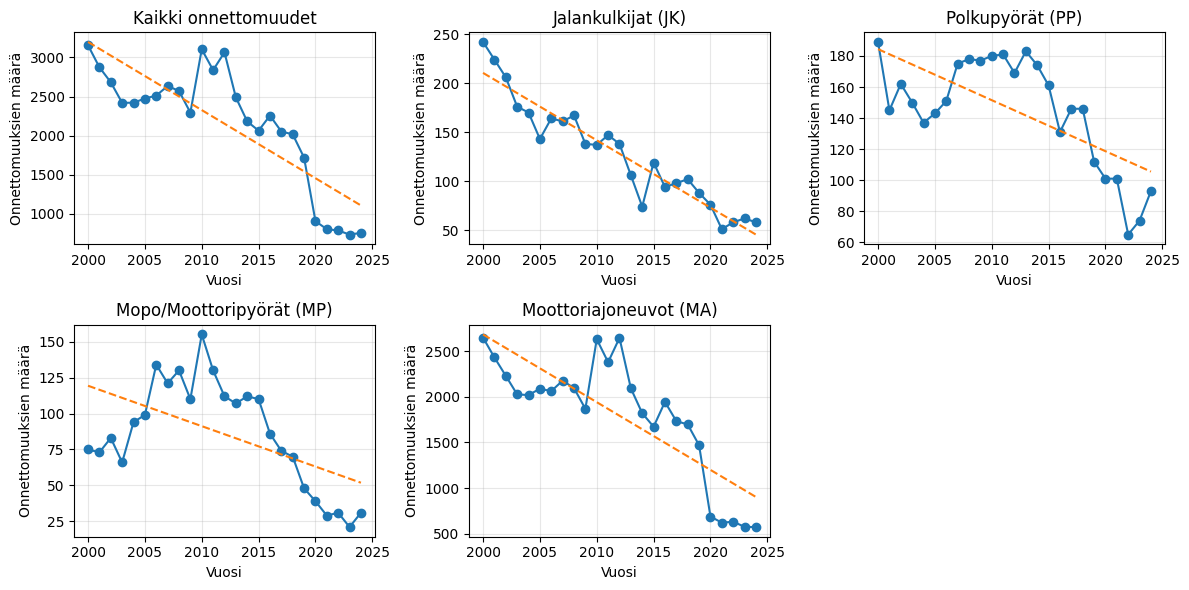

In [66]:
plot_accidents_by_year(project_df)

Onnettomuuksien kokonaismäärä on laskenut merkittävästi vuoden 2000 (3155) ja 2019 (1718) välillä.
Moottoriajoneuvo-onnettomuudet (MA) ovat selvästi yleisin tyyppi kattaen noin 80-85% kaikista tapauksista.
Polkupyöräonnettomuudet (PP) ovat pysyneet suhteellisen vakaina muihin tyyppeihin verrattuna, kun taas
mopo/moottoripyöräonnettomuudet (MP) kasvoivat 2005-2010 ja ovat sen jälkeen laskeneet voimakkaasti.

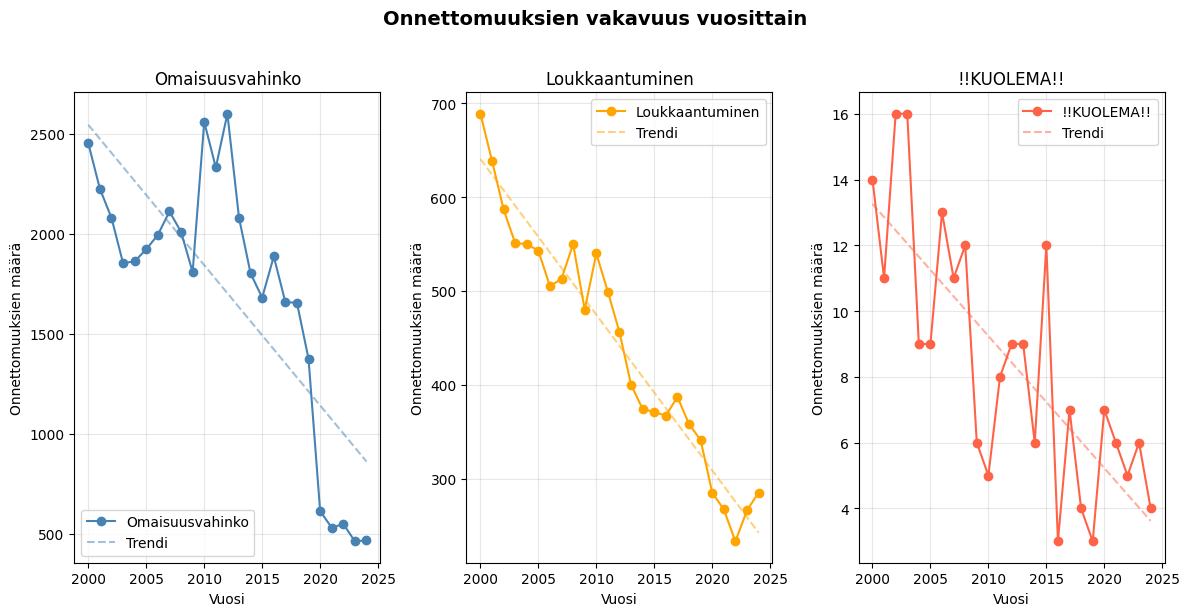

In [67]:
plot_seriousness_by_year(project_df)

Omaisuusvahinko-onnettomuudet ovat selvästi yleisin vakavuusluokka kattaen noin 75-80% kaikista tapauksista,
ja ne ovat laskeneet tasaisesti 2452:sta (2000) 1374:ään (2019).
Loukkaantumiseen johtaneet onnettomuudet ovat myös laskeneet 689:stä (2000) 341:een (2019).
Kuolemaan johtaneita onnettomuuksia on vuosittain erittäin vähän (3-16 tapausta),
ja niissä on myös havaittavissa laskeva trendi.

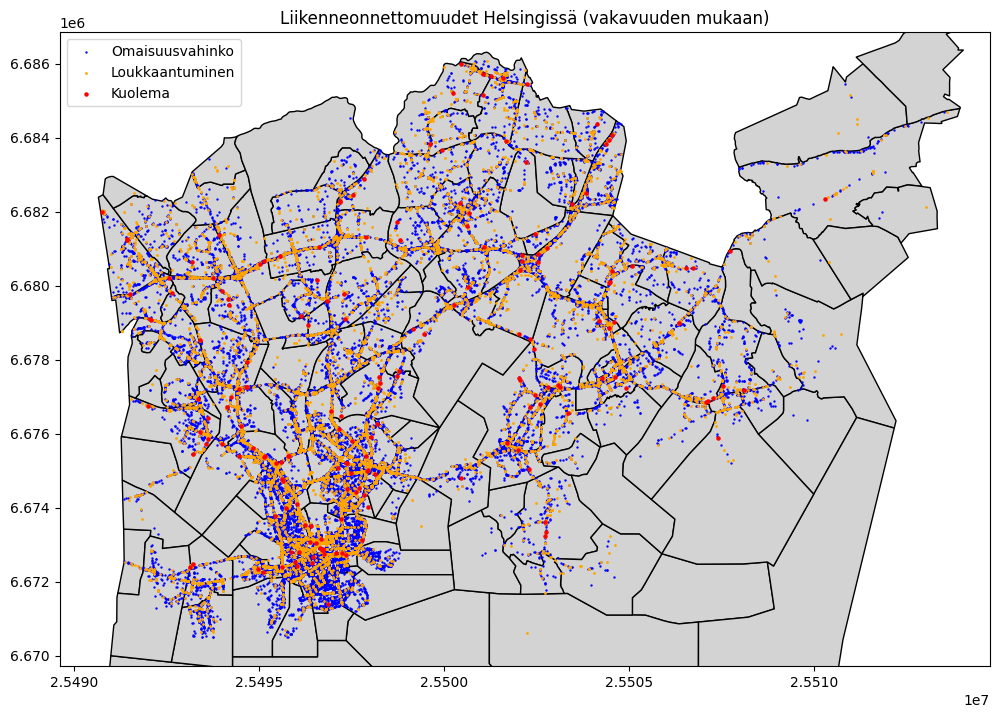

In [68]:
plot_map(project_df)

Kartasta voidaan havaita, että suurin osa onnettomuuksista keskittyy keskustan alueille. Lisäksi vakavimmat onnettomuudet erottuvat kartasta vilkkaiden väylien ja risteyksien läheisyydessä. 

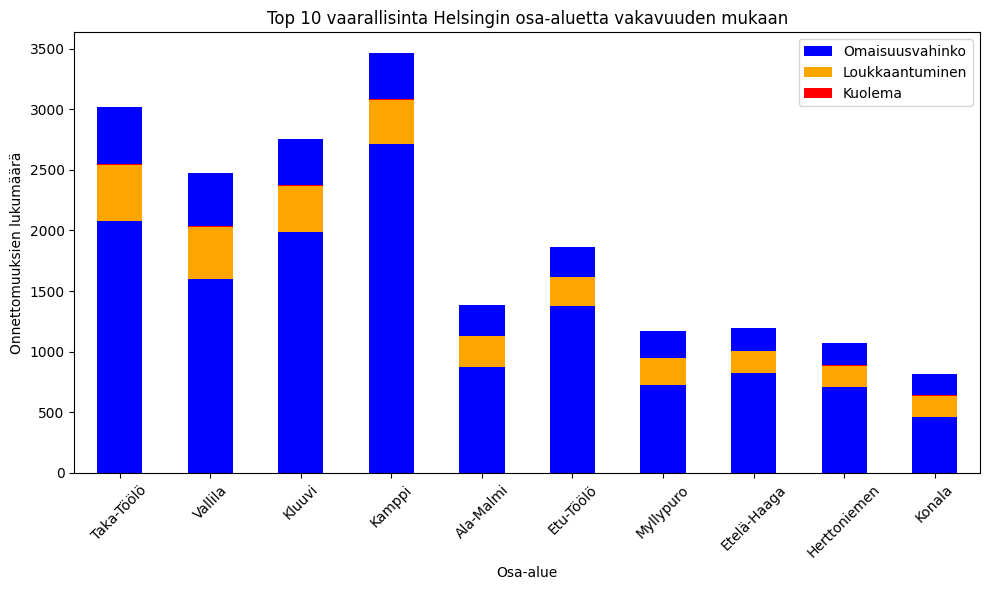

In [69]:
plot_accidents_by_place(project_df)

Pylväsdiagrammi todentaa havainnon, että suurin osa onnettomuuksista tapahtuu keskustan alueilla. Lisäksi kaaviosta huomataan, että omaisuusvahingot ovat yleisin onnettomuustyyppi, loukkaantumiset ovat harvinaisempia ja kuolemat kaikista harvinaisimpia.


## 3.0 Data preparation

Poistetaan puutteelliset rivit. Tämän jälkeen yhdistetään piirialuejako datasettiin.

In [70]:
rows_before = len(project_df)
project_df = project_df.dropna()
rows_after = len(project_df)

print(f"Pudotettiin {rows_before - rows_after} riviä.")

Pudotettiin 3 riviä.


Seuraavaksi yhdistetään piirialuejakotieto alkuperäiselle dataframelle erillisestä ``piirialuejako-1995-2019.gpkg`` tiedostosta. Tavoitteena lisätä siis kaupunginosa-sarake jokaiselle datariville, jotta voidaan nähdä suoraan mihin kaupunginosaan mikäkin datarivi sijoittuu.

In [71]:
accidents = gpd.GeoDataFrame(
    project_df,
    geometry=gpd.points_from_xy(project_df["ita_etrs"], project_df["pohj_etrs"]),
    crs="EPSG:3879"
)
areas = areas.to_crs(accidents.crs)

accidents = gpd.sjoin(
    accidents,
    areas[["Nimi", "geometry"]],
    how="left",
    predicate="within"
)

accidents = accidents.rename(columns={"Nimi": "Osa-alue"})
accidents = accidents.drop(columns=["geometry", "index_right"])

Uudelleennimetään ja uudelleenjärjestetään sarakkeet selkeyden vuoksi.

In [72]:
col_rename = {"LAJI": "O_Tyyppi", "pohj_etrs": "Pohj_coords", "ita_etrs": "Itä_coords","VAKAV_A": "Vakavuus", "VV": "Vuosi"}
accidents = accidents.rename(columns=col_rename)
accidents = accidents.iloc[:, [1, 2, 5, 0, 4, 3]]
accidents.head()

,Pohj_coords,Itä_coords,Osa-alue,O_Tyyppi,Vuosi,Vakavuus
0,6675786.73,25501661.91,Länsi-Hertto,JK,2022,1
1,6674533.32,25502790.94,Yliskylä,JK,2022,2
2,6679536.47,25506837.81,Mellunmäki,JK,2022,2
3,6675297.68,25498807.13,Kalasatama,JK,2022,2
4,6674924.21,25495525.13,Taka-Töölö,JK,2022,2


Nyt nähdään ETRS-GK25 (EPSG 3879) koordinaatiston kautta lisätyt kaupunginosatiedot on nyt yhdistetty taulukkoon.

Muutetaan data-arvot kategorisiksi/numeerisiksi arvoiksi, jotta niitä voidaan myöhemmin käyttää mallissa.

In [73]:
print(accidents.dtypes)

Pohj_coords      str
Itä_coords       str
Osa-alue         str
O_Tyyppi         str
Vuosi          int64
Vakavuus       int64
dtype: object


In [74]:
cols_to_categorical = ["Osa-alue", "O_Tyyppi"]
accidents[cols_to_categorical] = accidents[cols_to_categorical].astype("category")

cols_to_float = ["Pohj_coords", "Itä_coords"]
accidents[cols_to_float] = accidents[cols_to_float].astype(float)

Tarkistetaan setin datatyypit.

In [75]:
print(accidents.dtypes)

Pohj_coords     float64
Itä_coords      float64
Osa-alue       category
O_Tyyppi       category
Vuosi             int64
Vakavuus          int64
dtype: object


Viimeiseksi poistetaan vuodet 2019 jälkeen, koska avoindata.suomi.fi-sivuston mukaan data päivitettiin viimeksi 15. tammikuuta 2020, joten vuoden 2020 jälkeiset tiedot voivat olla puutteellisia tai virheellisiä.

In [76]:
accidents = accidents[accidents["Vuosi"] <= 2019]

In [77]:
accidents.describe(include='all')

,Pohj_coords,Itä_coords,Osa-alue,O_Tyyppi,Vuosi,Vakavuus
count,4.981900e+04,4.981900e+04,49809,49819,49819.000000,49819.000000
unique,NaN,NaN,140,4,NaN,NaN
top,NaN,NaN,Kamppi,MA,NaN,NaN
freq,NaN,NaN,3087,41746,NaN,NaN
mean,6.676551e+06,2.549789e+07,NaN,NaN,2008.933620,1.202051
std,3.494570e+03,3.636920e+03,NaN,NaN,5.633834,0.410581
min,6.670495e+06,2.549076e+07,NaN,NaN,2000.000000,1.000000
25%,6.673281e+06,2.549564e+07,NaN,NaN,2004.000000,1.000000
50%,6.675890e+06,2.549699e+07,NaN,NaN,2009.000000,1.000000
75%,6.679402e+06,2.549983e+07,NaN,NaN,2013.000000,1.000000


### 3.1 Data preparing - Linear Regression

Ryhmitellään onnettomuudet alueittain ja vuosittain. Lasketaan uudet piirteet:
- `onnettomuudet`: alueen ja vuoden onnettomuuksien määrä
- `vakavuus_mean`: onnettomuuksien keskimääräinen vakavuus
- `pohj` / `ita`: keskiarvokoordinaatit, jotka edustavat alueen keskikohtaa

In [78]:
# Peruskooste: onnettomuuksien määrä + vakavuus + koordinaatit alueittain ja vuosittain
yearly_area_accidents = accidents.groupby(['Osa-alue', 'Vuosi']).agg(
    onnettomuudet=('Osa-alue', 'size'),
    vakavuus_mean=('Vakavuus', 'mean'),
    pohj=('Pohj_coords', 'mean'),
    ita=('Itä_coords', 'mean'),
).reset_index()

Onnettomuustyyppien osuudet (O_Tyyppi) alueittain ja vuosittain. Lasketaan kunkin onnettomuustyypin määrä alueittain ja vuosittain.
Muutetaan ne osuuksiksi (prosenttiosuudet alueen kaikista onnettomuuksista)

In [79]:
type_counts = (
    accidents.groupby(['Osa-alue', 'Vuosi', 'O_Tyyppi'])
    .size()
    .unstack(fill_value=0)
)

Lasketaan osuudet kunkin tyypin kohdalla

In [80]:
type_props = type_counts.div(type_counts.sum(axis=1), axis=0)
type_props.columns = [f'tyyppi_{c}_osuus' for c in type_props.columns]

Liitetään osuudet alkuperäiseen yhteenvetoon

In [81]:
yearly_area_accidents = yearly_area_accidents.merge(
    type_props.reset_index(), on=['Osa-alue', 'Vuosi'], how='left'
)

Viivästetyt muuttujat (lag-piirteet)
Lisätään edellisen vuoden onnettomuusmäärä, vakavuuden keskiarvo ja summa kullekin alueelle.

 - `onnettomuudet_lag1`: edellisen vuoden onnettomuuksien määrä
 - `vakavuus_mean_lag1`: edellisen vuoden vakavuuden keskiarvo

 Tämä auttaa mallia hyödyntämään ajallista riippuvuutta


In [82]:
yearly_accidents = yearly_area_accidents.sort_values(['Osa-alue', 'Vuosi'])

# Luodaan lag-piirteet
lag_cols = ['onnettomuudet', 'vakavuus_mean']
for col in lag_cols:
    yearly_accidents[f'{col}_lag1'] = (
        yearly_accidents.groupby('Osa-alue')[col].shift(1) # Siirretään arvot yhdellä vuodella taaksepäin
    )

# Poistetaan rivit, joissa lag-arvoja ei ole (ensimmäinen vuosi)
yearly_accidents = yearly_accidents.dropna()
print(yearly_accidents.head())

    Osa-alue  Vuosi  onnettomuudet  vakavuus_mean          pohj           ita  \
1  Ala-Malmi   2001             65       1.200000  6.681320e+06  2.550079e+07   
2  Ala-Malmi   2002             48       1.250000  6.681349e+06  2.550080e+07   
3  Ala-Malmi   2003             51       1.274510  6.681331e+06  2.550087e+07   
4  Ala-Malmi   2004             47       1.404255  6.681330e+06  2.550067e+07   
5  Ala-Malmi   2005             61       1.327869  6.681374e+06  2.550077e+07   

   tyyppi_JK_osuus  tyyppi_MA_osuus  tyyppi_MP_osuus  tyyppi_PP_osuus  \
1         0.046154         0.846154         0.000000         0.107692   
2         0.062500         0.875000         0.041667         0.020833   
3         0.019608         0.784314         0.019608         0.176471   
4         0.106383         0.744681         0.021277         0.127660   
5         0.065574         0.836066         0.016393         0.081967   

   onnettomuudet_lag1  vakavuus_mean_lag1  
1                63.0         

Jako opetus- ja testijoukkoon. Opetusjoukkona käytetään vuosia ennen 2019. Testijoukkona käytetään vuotta 2019, jonka tuloksia verrataan mallin ennusteisiin.

In [83]:
train_data = yearly_accidents[yearly_accidents['Vuosi'] <= 2018].copy()
test_data = yearly_accidents[yearly_accidents['Vuosi'] == 2019].copy()

Käytetään koordinaatteja jatkuvina muuttujina alueen sijaan
- Välttää liian monta dummy-saraketta.
- Malli voi oppia sijainnin lineaarisen vaikutuksen.

In [84]:
feature_cols = (
    ['onnettomuudet_lag1', 'vakavuus_mean_lag1', 'pohj', 'ita']
    + [c for c in yearly_accidents.columns if c.startswith('tyyppi_')]
)

Opetus- ja testijoukon piirteet ja tavoitemuuttuja

In [85]:
X_tr = train_data[feature_cols] # Piirteet (lagit, koordinaatit, tyyppiosuudet)
y_tr = train_data['onnettomuudet'] # Tavoitemuuttuja: onnettomuuksien määrä

X_te = test_data[feature_cols]
y_te = test_data['onnettomuudet']

Tarkastellaan piirteiden välistä korrelaatiota
Tämä auttaa havaitsemaan mahdollisen multikollineaarisuuden

In [86]:
corr = X_tr.corr()
print(corr)

                    onnettomuudet_lag1  vakavuus_mean_lag1      pohj  \
onnettomuudet_lag1            1.000000           -0.137304 -0.258786   
vakavuus_mean_lag1           -0.137304            1.000000  0.135699   
pohj                         -0.258786            0.135699  1.000000   
ita                          -0.165390            0.021473  0.246354   
tyyppi_JK_osuus               0.049569           -0.011566 -0.060864   
tyyppi_MA_osuus               0.110311           -0.052919 -0.104674   
tyyppi_MP_osuus              -0.090449            0.033729  0.150597   
tyyppi_PP_osuus              -0.111202            0.053053  0.059085   

                         ita  tyyppi_JK_osuus  tyyppi_MA_osuus  \
onnettomuudet_lag1 -0.165390         0.049569         0.110311   
vakavuus_mean_lag1  0.021473        -0.011566        -0.052919   
pohj                0.246354        -0.060864        -0.104674   
ita                 1.000000        -0.020143        -0.028966   
tyyppi_JK_osuus    -0

Korrelaation arvo vaihtelee -1 ja 1 välillä. Arvo 1 tarkoittaa täydellistä lineaarista riippuvuutta ja -1 täydellistä negatiivista riippuvuutta. Arvo 0 tarkoittaa, ettei lineaarista riippuvuutta ole.
Heikko korrelaatio `onnettomuudet_lag1` - `vakavuus_mean_lag1` (~ 0.14) ja `tyyppi_JK_osuus` - `ita` (~ 0.02)
Vahva korrelaatio `tyyppi_MA_osuus` - `tyyppi_PP_osuus` (~ 0.64)

Standardoidaan piirteet, jotta kaikki muuttujat ovat samalla mittakaavalla
Tämä parantaa lineaarisen regression vakautta ja tekee kertoimista vertailukelpoisia

In [87]:
scaler = StandardScaler()
X_tr_scaled = pd.DataFrame(scaler.fit_transform(X_tr), columns=feature_cols)
X_te_scaled  = pd.DataFrame(scaler.transform(X_te),      columns=feature_cols)

## 4.0 Modeling

### 4.1 Random Forest

Käytetään Random Forest -mallia, jonka avulla pyritään ennustamaan onnettomuuden vakavuutta käyttäen sijaintia, kaupunginosaa ja onnettomuustyyppiä.

### 4.11 Feature preparation

Muutetaan kategoriset muuttujat one-hot-encodauksella numeeriseen muotoon, jotta malli voi käyttää sitä.

In [88]:
model_df = accidents.copy()
model_df = pd.get_dummies(
    model_df,
    columns=["Osa-alue", "O_Tyyppi"]
)

### 4.12 Feature ja target muuttujat

In [89]:
X = model_df.drop("Vakavuus", axis=1)
y = model_df["Vakavuus"]

### 4.13 Train-test split

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### 4.14 Random Forest -mallin koulutus

In [91]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=3,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### 4.2 Linear Regression

Luodaan lineaarisen regression malli ja sovitetaan se opetusjoukkoon

In [92]:
linear_model = LinearRegression()
linear_model.fit(X_tr_scaled, y_tr)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Tulostetaan mallin vakiotermi ja piirteiden kertoimet

In [93]:
print("Linear-regressiomallin parametrit:")
print(f"Vakiotermi (intercept): {linear_model.intercept_:.3f}")
for name, coef in zip(feature_cols, linear_model.coef_):
    print(f"  {name}: {coef:.3f}")

Linear-regressiomallin parametrit:
Vakiotermi (intercept): 20.412
  onnettomuudet_lag1: 25.110
  vakavuus_mean_lag1: 0.153
  pohj: -0.124
  ita: -0.089
  tyyppi_JK_osuus: 0.015
  tyyppi_MA_osuus: 0.142
  tyyppi_MP_osuus: 0.033
  tyyppi_PP_osuus: -0.238


Vakiotermi (intercept = 20.412) on ennuste, kun kaikki piirteet ovat 0 (lähtöpiste). Suurempi `coef` sen voimakkaampi vaikutus ennusteeseen.  Positiivinen arvo lisää ennustetta ja kun taas negatiivinen vähentää.
- Lag-piirteet (edellisen vuoden arvot) `onnettomuudet_lag1 = 25.110` on suurin vaikutus, edellisen vuoden onnettomuudet selittävät vahvasti seuraavan vuoden määrää. `vakavuus_mean_lag1 = 0.153` taas pieni positiivinen vaikutus.
- Koordinaateilla  `pohj = -0.124`, `ita = -0.089` sijainneilla pieni negatiivinen vaikutus.
- Onnettomuustyyppien osuudet: `tyyppi_PP_osuus = -0.238`, `tyyppi_MA_osuus = 0.142` Muiden tyyppien osuudet vähäinen vaikutus



## 5.0 Evaluation

### 5.1 Random Forest Evaluation

Arvioidaan Random Forest-mallin suorituskykyä.

In [94]:
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Mallin tarkkuus:", accuracy)
confusion_matrix(y_test, y_pred)

Mallin tarkkuus: 0.8259735046166198


array([[7457,  473,   86],
       [ 900,  760,  250],
       [  11,   14,   13]])

Testauksen mielessä kokeillaan useammalla eri parametreilla Random Forest - mallin kouluttamisen seurauksesta näkyviä tarkkuuksia.

In [95]:
results = []

for depth in [5, 10, 15]:           # Syvyydet 
    for trees in [100, 200, 300]:   # n_estimators

        rf = RandomForestClassifier(
            n_estimators=trees,
            max_depth=depth,
            min_samples_leaf=3,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42         # sama pysyvä random_state kaikissa
        )

        rf.fit(X_train, y_train)

        preds = rf.predict(X_test)
        acc = accuracy_score(y_test, preds)

        results.append({
            "max_depth": depth,
            "n_estimators": trees,
            "accuracy": acc
        })

results_df = pd.DataFrame(results)

print(results_df)

   max_depth  n_estimators  accuracy
0          5           100  0.808611
1          5           200  0.808009
2          5           300  0.808410
3         10           100  0.827880
4         10           200  0.825974
5         10           300  0.824769
6         15           100  0.837515
7         15           200  0.836411
8         15           300  0.835709


Tarkkuus huomataan pyörivän **80-85 %** välillä, koska suurin osa onnettomuuksista kuuluu vakavuusluokkaan 1.

Valitaan malli, jonka tarkkuus oli muita suurempi, ja tämän jälkeen uudelleenkoulutetaan malli sen parhaan mallin hyperparatmerien mukaisesti.

In [96]:
best_model = results_df.loc[results_df["accuracy"].idxmax()]

print("Paras malli:")
print(best_model)

Paras malli:
max_depth        15.000000
n_estimators    100.000000
accuracy          0.837515
Name: 6, dtype: float64


In [97]:
best_rf = RandomForestClassifier(
    n_estimators=int(best_model["n_estimators"]),
    max_depth=int(best_model["max_depth"]),
    min_samples_leaf=3,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)

best_rf.fit(X_train, y_train)

y_pred_best = best_rf.predict(X_test)

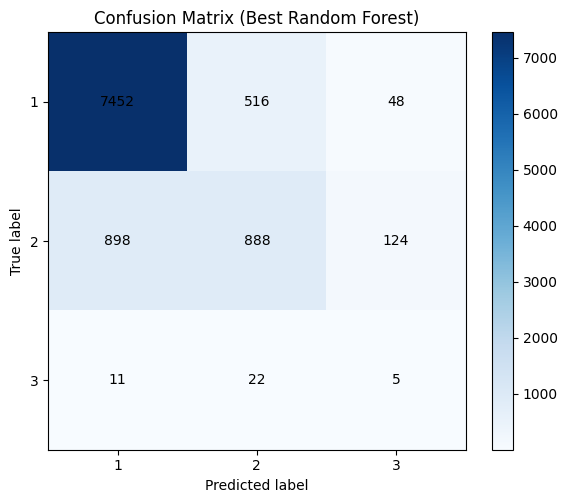

[[7452  516   48]
 [ 898  888  124]
 [  11   22    5]]


In [98]:
cm = confusion_matrix(y_test, y_pred_best)
labels = np.unique(np.concatenate([y_test.values, y_pred_best]))

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix (Best Random Forest)")
plt.colorbar()

tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

print(cm)

In [99]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           1       0.89      0.93      0.91      8016
           2       0.62      0.46      0.53      1910
           3       0.03      0.13      0.05        38

    accuracy                           0.84      9964
   macro avg       0.51      0.51      0.50      9964
weighted avg       0.84      0.84      0.83      9964



Random Forest -malli pääsi testidatalla noin 84% tarkkuuteen. Malli suoriutui todella hyvin vakavuusluokassa (1), jossa oli F1-score 0.91.

Vakavuusluokka (2):n ennustaminen oli selkeästi haastavampaa.

Vakavuusluokka (3):n ennustaminen oli huomattavasti heikoimpaa, mikä johtuu datan epäatasapainosta. Tapauksia, jotka kuuluivat vakavuusluokkaan (3) datasetissä oli vain 38 tapausta, minkä vuoksi koneoppimismallin on vaikea oppia tunnistamaan tätä luokkaa luotettavasti.

### 5.2 Linear regression

Ennustetaan onnettomuudet opetus- ja testijoukoille

In [100]:
train_preds = linear_model.predict(X_tr_scaled)
test_preds  = linear_model.predict(X_te_scaled)

Piirretään residuaalit (todelliset − ennustetut) vs. ennustetut arvot. Residuaalit näyttävät, kuinka paljon malli yli- tai aliarvioi ennusteet

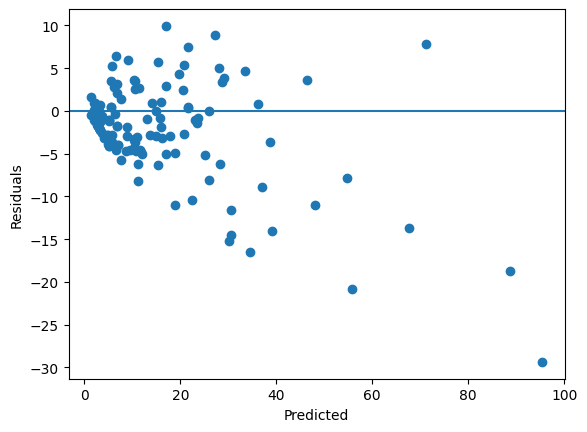

In [101]:
residuals = y_te - test_preds

plt.scatter(test_preds, residuals)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

Kuvassa näkyy, että pisteet ovat pääosin lähellä nollaa. Mitä suuremmiksi residuaalit kasvavat, sitä enemmän malli ennustaa liian suuria arvoja. Negatiiviset residuaalit tarkoittavat, että malli yliarvioi ennusteet, ja positiiviset residuaalit, että malli aliarvioi niitä. Kuva osoittaa, että malli hieman yliarvioi korkeita ennusteita, ja meidän tapauksessamme malli ennustaa vuoden 2019 onnettomuudet hieman yli, mutta yleinen trendi on oikein.

Piirretään scatter-plot kuvaaja todellisista ja ennustetuista onnettomuuksista

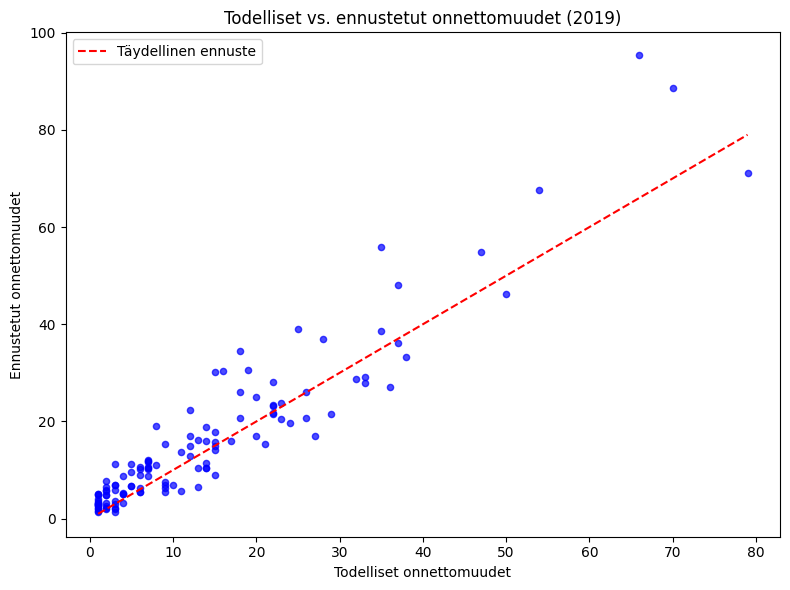


Total predicted accidents (2019): 1999
Total actual accidents (2019): 1718


In [102]:
plt.figure(figsize=(8, 6))
plt.scatter(y_te, test_preds, s=20, alpha=0.7, color='blue')
plt.plot(
    [y_te.min(), y_te.max()],
    [y_te.min(), y_te.max()],
    color='red', linestyle='--', label='Täydellinen ennuste'
)
plt.xlabel("Todelliset onnettomuudet")
plt.ylabel("Ennustetut onnettomuudet")
plt.title("Todelliset vs. ennustetut onnettomuudet (2019)")
plt.legend()
plt.tight_layout()
plt.show()

pred_2019_df = test_data[['Osa-alue']].copy()
pred_2019_df['Vuosi'] = 2019
pred_2019_df['predicted_accidents'] = test_preds
pred_2019_df['actual_accidents'] = y_te.values

total_pred_2019 = pred_2019_df['predicted_accidents'].sum()
total_actual_2019 = pred_2019_df['actual_accidents'].sum()

print(f"\nTotal predicted accidents (2019): {total_pred_2019:.0f}")
print(f"Total actual accidents (2019): {total_actual_2019:.0f}")

Jokainen piste kuvaa yhtä aluetta vuonna 2019.
- Pisteen x-koordinaatti kertoo todellisten onnettomuuksien määrän ja y-koordinaatti ennustetun määrän.
- Punainen katkoviiva näyttää täydellisen ennusteen; pisteen ollessa viivalla ennuste vastaa todellisuutta.
- Piste viivan yläpuolella tarkoittaa, että malli yliarvioi ennusteen,  kun taas piste viivan alapuolella tarkoittaa, että malli aliarvioi.
- Näin voidaan tarkastella kunkin alueen ennusteen tarkkuutta ja koko mallin yleistä trendiä.

### 5.22 Tehokkuus

- Lasketaan regressiomallin suorituskyky opetus- ja testijoukossa käyttäen seuraavia mittareita:
  - `R²` selitysaste, kertoo kuinka hyvin malli selittää havaittua vaihtelua
  - `MAE` (Mean Absolute Error): keskimääräinen absoluuttinen virhe
  - `RMSE`  (Root Mean Squared Error): keskimääräinen neliöjuurivirhe

In [103]:
r2_train   = r2_score(y_tr, train_preds)
mae_train  = mean_absolute_error(y_tr, train_preds)
rmse_train = np.sqrt(mean_squared_error(y_tr, train_preds))

r2_test    = r2_score(y_te, test_preds)
mae_test   = mean_absolute_error(y_te, test_preds)
rmse_test  = np.sqrt(mean_squared_error(y_te, test_preds))

print("OPETUSJOUKKO")
print(f"  R²: {r2_train:.4f} | MAE: {mae_train:.4f} | RMSE: {rmse_train:.4f}")

print("TESTIJOUKKO (2019)")
print(f"  R²: {r2_test:.4f} | MAE: {mae_test:.4f} | RMSE: {rmse_test:.4f}")

print("EROTUS (opetus − testi)")
print(f"  R²: {r2_train - r2_test:.4f} | MAE: {mae_train - mae_test:.4f} | RMSE: {rmse_train - rmse_test:.4f}")

OPETUSJOUKKO
  R²: 0.9119 | MAE: 5.0452 | RMSE: 7.8254
TESTIJOUKKO (2019)
  R²: 0.8190 | MAE: 4.3498 | RMSE: 6.2947
EROTUS (opetus − testi)
  R²: 0.0929 | MAE: 0.6953 | RMSE: 1.5307


Malli selittää hyvin vaihtelua sekä opetus- että testijoukossa (korkeat R²-arvot). Pienet erot opetus- ja testijoukon mittareissa osoittavat, että malli yleistyy hyvin uusiin datoihin eikä ylitäoppine. RMSE ja MAE ovat kohtuullisen pieniä suhteessa onnettomuuksien lukumääriin, mikä tukee mallin toimivuutta opetusesimerkissä.

### 5.23 Predicting year 2020 accidents

Lasketaan vuoden 2019 piirteet lag-arvoiksi vuoden 2020 ennustetta varten. Lag-piirteet sisältävät edellisen vuoden (2019) onnettomuudet ja vakavuuden keskiarvon. Onnettomuustyyppien osuudet kopioidaan suoraan vuoden 2019 datasta.  Piirteet skaalataan samalla StandardScalerilla kuin opetusdata ja syötetään lineaariseen regressiomalliin ennustetta varten. Tulokset sisältävät kunkin alueen ennustetut onnettomuudet sekä kokonaisennusteen vuodelle 2020.

In [104]:
# Lasketaan 2019 piirteet lag-arvoiksi 2020 ennustetta varten
data_2019 = yearly_accidents[yearly_accidents['Vuosi'] == 2019].copy()

predict_2020 = data_2019[['Osa-alue', 'pohj', 'ita']].copy()

# Viime vuoden (2019) arvot lag-piirteiksi
predict_2020['onnettomuudet_lag1'] = data_2019['onnettomuudet'].values
predict_2020['vakavuus_mean_lag1'] = data_2019['vakavuus_mean'].values

# Onnettomuustyyppien osuudet 2019 datasta
for col in [c for c in data_2019.columns if c.startswith('tyyppi_')]:
    predict_2020[col] = data_2019[col].values

# Skaalaus ja ennuste
X_2020 = predict_2020[feature_cols]
X_2020_scaled = pd.DataFrame(scaler.transform(X_2020), columns=feature_cols)
preds_2020 = linear_model.predict(X_2020_scaled)

predict_2020['ennustettu_2020'] = preds_2020
print(predict_2020[['Osa-alue', 'ennustettu_2020']])
print(f"\nYhteensä ennustettu 2020: {preds_2020.sum():.0f}")

          Osa-alue  ennustettu_2020
19       Ala-Malmi        33.129624
37       Alppikylä         1.839792
57         Alppila        12.602730
75    Arabianranta         2.359094
93    Aurinkolahti         2.894775
...            ...              ...
2391   Viikinranta        14.379494
2411   Vilhonvuori        14.791059
2431      Yliskylä         7.596624
2451     Ylä-Malmi         3.844284
2462   Östersundom         6.971469

[123 rows x 2 columns]

Yhteensä ennustettu 2020: 1722


Ennuste osoittaa mallin pystyvän arvioimaan aluekohtaisia trendejä myös tulevalle vuodelle, vaikka absoluuttiset arvot voivat hieman poiketa todellisuudesta.

## 6.0 Deployment

### 6.1 Linear regression - Deployment

Datasetin visualisointi osoitti, että vuosittaiset onnettomuusmäärät ovat melko "kohinaisia". Liikenneonnettomuuksiin vaikuttavat monet ulkoiset tekijät, joita datasetissä ei ole mukana, kuten liikennesääntöjen muutokset, uudet turvallisemmat tiet ja muut erikoistapaukset. Mallilla ennustaminen vuodelle 2019 R²-arvolla 0.8190 onnistui hyvin, mutta tulevien vuosien ennustaminen ei ole yhtä tarkkaa, koska ulkoiset tekijät muuttuvat. Esimerkiksi koronapandemian alkaessa 2020 liikenneonnettomuudet vähenivät merkittävästi, mikä ei olisi mallin ennustettavissa. Mallia voidaan kuitenkin käyttää **analysoimaan hypotettisia skenaarioita**, kuten arvioida onnettomuusmääriä ilman poikkeustekijöitä:
